## Exploratory_Analysis_of_Chennai’s_Reservoir_Trends

# Chennai Reservoir Data Analysis

This project analyzes daily water storage levels in four major reservoirs of Chennai — Poondi, Cholavaram, Redhills, and Chembarambakkam — using Python.

We clean and explore the data, visualize seasonal trends, calculate cumulative storage, and study correlations between reservoirs.


## Dataset Overview

- Daily storage values for each reservoir
- Covers multiple years
- Includes derived columns: `Total`, `Cumulative`, `Month`, `Year`


## Data Cleaning & Preparation

- Converted date column to datetime
- Extracted `year` and `month`
- Calculated `Total` (sum of 4 reservoirs)
- Filled missing values with 0


## Daily Total Storage

Shows daily fluctuations in total reservoir storage. Peaks indicate rainy periods.


## Monthly Average Storage

Bar plot showing average total storage for each calendar month, averaged over all years. Helps identify seasonal patterns.



## Project Structure
```bash
chennai-reservoir-analysis/
├── data/
│   └── chennai_reservoir_data.csv
├── plots/
│   └── [visual output files]
├── report/
│   └── reservoir_report.ipynb
├── reservoir_analysis.py
├── requirements.txt
└── README.md


### Step 1: Import libraries 

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Create folders to save output 
os.makedirs("plots", exist_ok=True)
os.makedirs("data", exist_ok=True)
os.makedirs("report", exist_ok=True)

### Step 2: Load the Data set 

In [3]:
# Load the data set 
df = pd.read_csv("data/chennai_reservoir_levels.csv")
df.head()

,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM
0,01-01-2004,3.9,0.0,268.0,0.0
1,02-01-2004,3.9,0.0,268.0,0.0
2,03-01-2004,3.9,0.0,267.0,0.0
3,04-01-2004,3.9,0.0,267.0,0.0
4,05-01-2004,3.8,0.0,267.0,0.0


### Step 3: Data cleaning an Preparation 

In [4]:
# Convert date with known format to suppress warning
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

# Extract year and month from date
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month

# If 'Total' column doesn't exist, calculate it as sum of 4 reservoirs
if 'Total' not in df.columns:
    df['Total'] = df[['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM']].sum(axis=1)

# Select and reorder specific columns:
df = df[['Date', 'year', 'month', 'POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM', 'Total']]

# Fill missing values with 0 for simplicity
df.fillna(0, inplace=True)

# Save cleaned data
df.to_csv("data/cleaned_reservoir_data.csv", index=False)
df.head()

,Date,year,month,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM,Total
0,2004-01-01,2004,1,3.9,0.0,268.0,0.0,271.9
1,2004-01-02,2004,1,3.9,0.0,268.0,0.0,271.9
2,2004-01-03,2004,1,3.9,0.0,267.0,0.0,270.9
3,2004-01-04,2004,1,3.9,0.0,267.0,0.0,270.9
4,2004-01-05,2004,1,3.8,0.0,267.0,0.0,270.8


### Steo 4: Summary Statistics

In [5]:
print(df.describe())



              year        month       POONDI   CHOLAVARAM     REDHILLS  \
count  5647.000000  5647.000000  5647.000000  5647.000000  5647.000000   
mean   2011.237294     6.427307  1130.442736   239.668881  1564.971215   
std       4.468135     3.452166  1027.019268   274.755326   892.471797   
min    2004.000000     1.000000     0.000000     0.000000     0.000000   
25%    2007.000000     3.000000   210.500000    22.000000   843.500000   
50%    2011.000000     6.000000   778.000000    92.000000  1627.000000   
75%    2015.000000     9.000000  2006.000000   459.500000  2234.000000   
max    2019.000000    12.000000  3231.000000   896.000000  3300.000000   

       CHEMBARAMBAKKAM         Total  
count      5647.000000   5647.000000  
mean       1318.411927   4253.494758  
std         957.842376   2968.805386  
min           0.000000      0.000000  
25%         467.000000   1721.500000  
50%        1221.000000   3750.000000  
75%        2080.000000   6553.000000  
max        3396.00000

In [6]:
monthly_avg = df.groupby("month")['Total'].mean()
yearly_total = df.groupby("year")['Total'].sum()

In [7]:
# Save summary
monthly_avg.to_csv("data/monthly_avg.csv")
yearly_total.to_csv("data/yearly_total.csv")

In [8]:
df.head()

,Date,year,month,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM,Total
0,2004-01-01,2004,1,3.9,0.0,268.0,0.0,271.9
1,2004-01-02,2004,1,3.9,0.0,268.0,0.0,271.9
2,2004-01-03,2004,1,3.9,0.0,267.0,0.0,270.9
3,2004-01-04,2004,1,3.9,0.0,267.0,0.0,270.9
4,2004-01-05,2004,1,3.8,0.0,267.0,0.0,270.8


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5647 entries, 0 to 5646
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             5647 non-null   datetime64[ns]
 1   year             5647 non-null   int64         
 2   month            5647 non-null   int64         
 3   POONDI           5647 non-null   float64       
 4   CHOLAVARAM       5647 non-null   float64       
 5   REDHILLS         5647 non-null   float64       
 6   CHEMBARAMBAKKAM  5647 non-null   float64       
 7   Total            5647 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 353.1 KB


### Step 5: Visualization

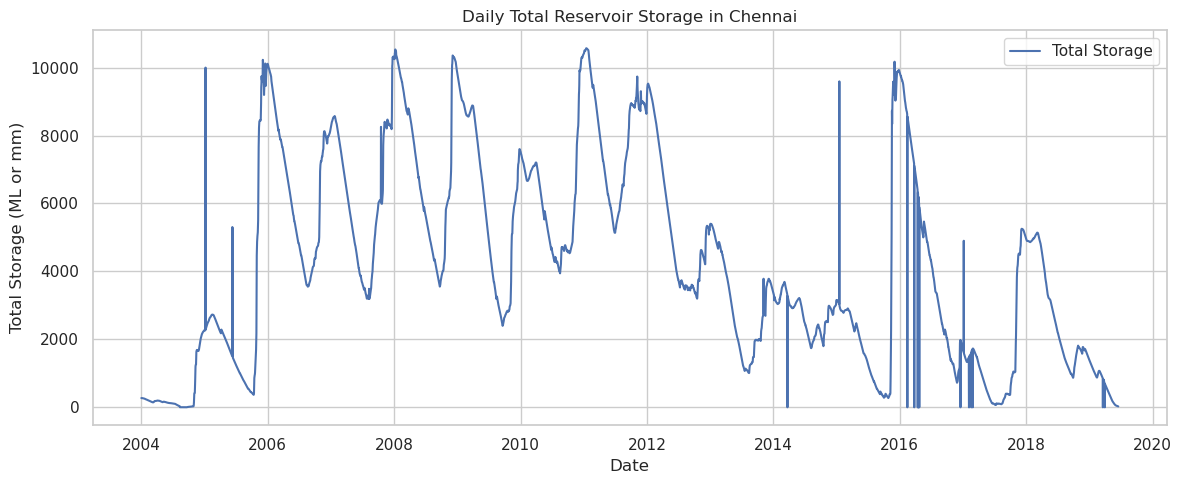

In [10]:
sns.set(style="whitegrid")

# 1. Daily Reservoir Storage Trend
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Total'], label="Total Storage")
plt.xlabel("Date")
plt.ylabel("Total Storage (ML or mm)")
plt.title("Daily Total Reservoir Storage in Chennai")
plt.legend()
plt.tight_layout()
plt.savefig("plots/daily_total_storage.png")
plt.show()

/tmp/ipykernel_1362466/312858174.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette="Blues_d")


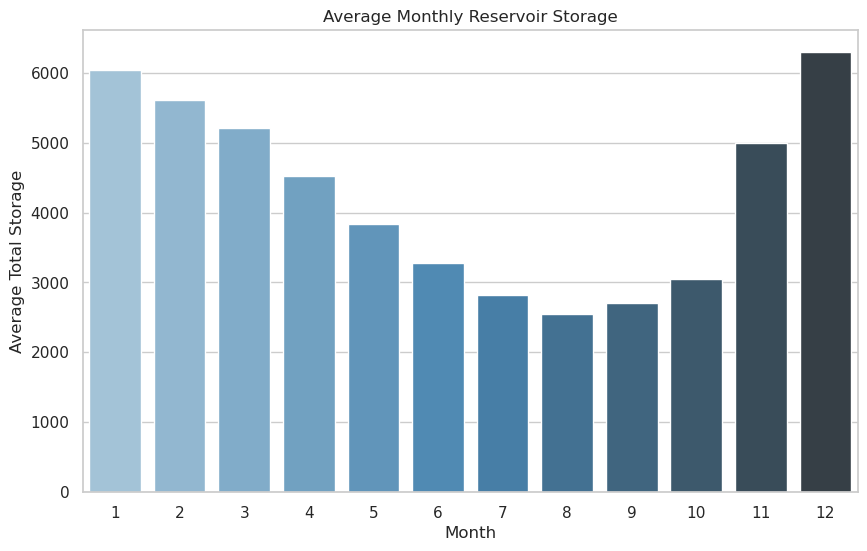

In [11]:

# 2. Monthly Average Storage
plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette="Blues_d")
plt.xlabel("Month")
plt.ylabel("Average Total Storage")
plt.title("Average Monthly Reservoir Storage")
plt.savefig("plots/monthly_avg_storage.png")
plt.show()

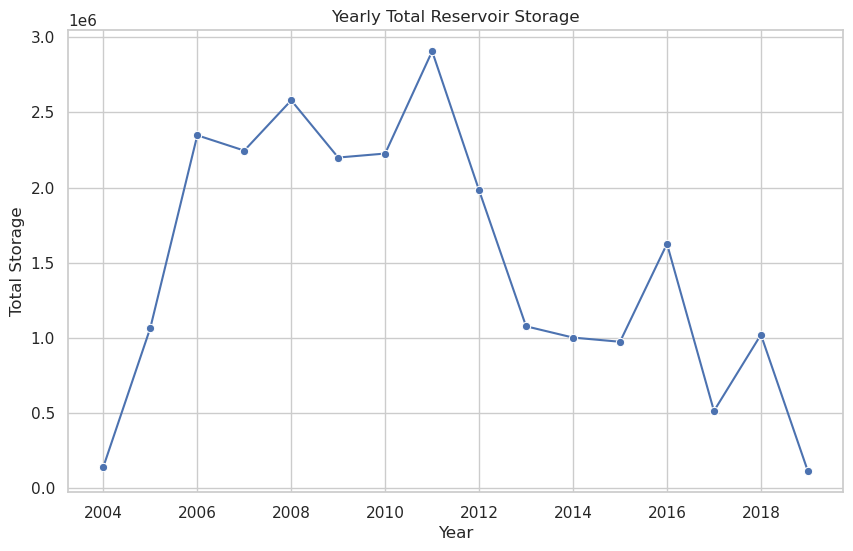

In [12]:
#3. Yearly Total Storage
plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_total.index, y=yearly_total.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Total Storage")
plt.title("Yearly Total Reservoir Storage")
plt.savefig("plots/yearly_total_storage.png")
plt.show()


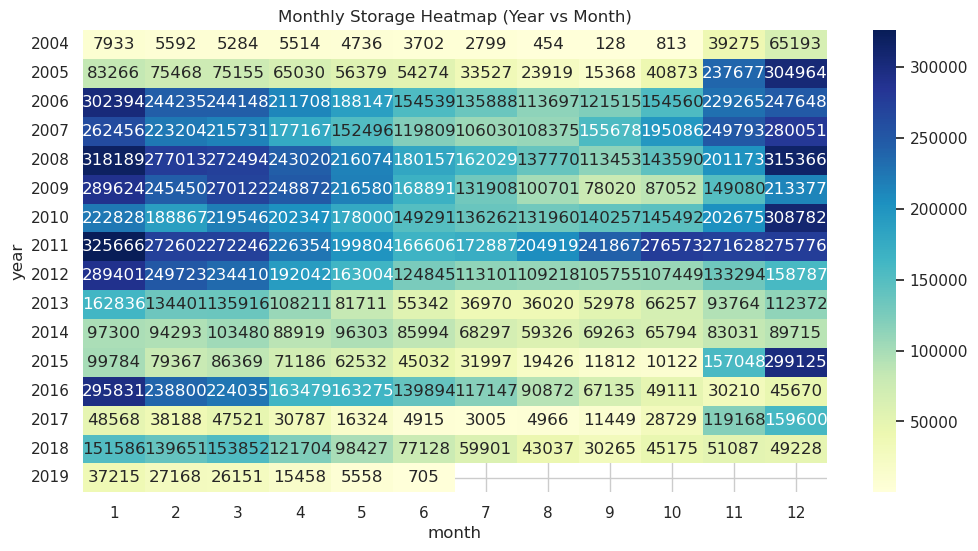

In [13]:

# 4. Heatmap of Monthly Storage by Year
pivot = df.pivot_table(values='Total', index='year', columns='month', aggfunc='sum')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Monthly Storage Heatmap (Year vs Month)")
plt.savefig("plots/monthly_heatmap.png")
plt.show()

####  What is Correlation?

    Correlation measures how two variables move together.

    Values range from -1 to 1:

        +1: perfect positive correlation (when one increases, the other increases)

        0: no correlation

        -1: perfect negative correlation (when one increases, the other decreases)

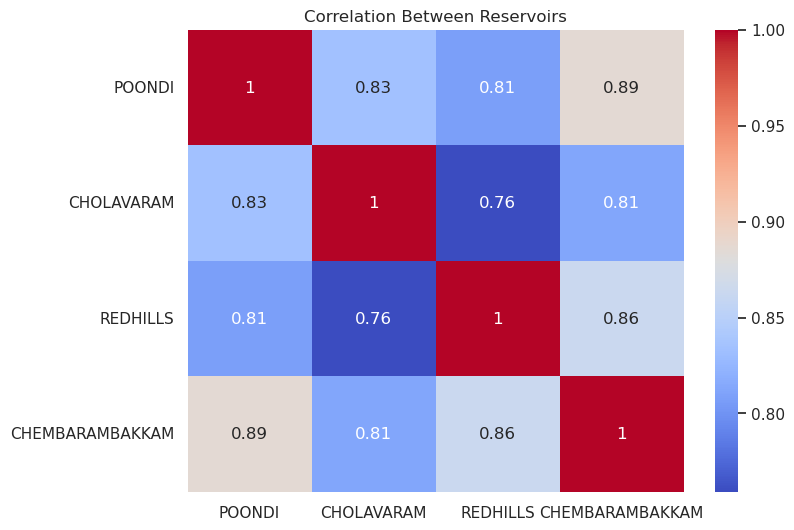

In [14]:
# 5. Correlation Between Reservoirs
plt.figure(figsize=(8, 6))
sns.heatmap(df[['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Reservoirs")
plt.savefig("plots/reservoir_correlation.png")
plt.show()

What is the use of a Cumulative Storage Plot?

The cumulative storage plot helps you understand how much water has been stored in total over time — it's not just showing daily values, but how they add up day-by-day. Why is this useful?

    Tracks long-term accumulation:
    You can see how much water was stored from the beginning up to any day.

    Highlights seasonal patterns:

        A steep slope in the plot = heavy rainfall / rapid storage gain.

        A flat line = dry season / no rainfall.

    Useful for planning:

        Water management teams can estimate total capacity reached by a certain time.

        It helps answer: "By June, how much water have we collected so far this year?"

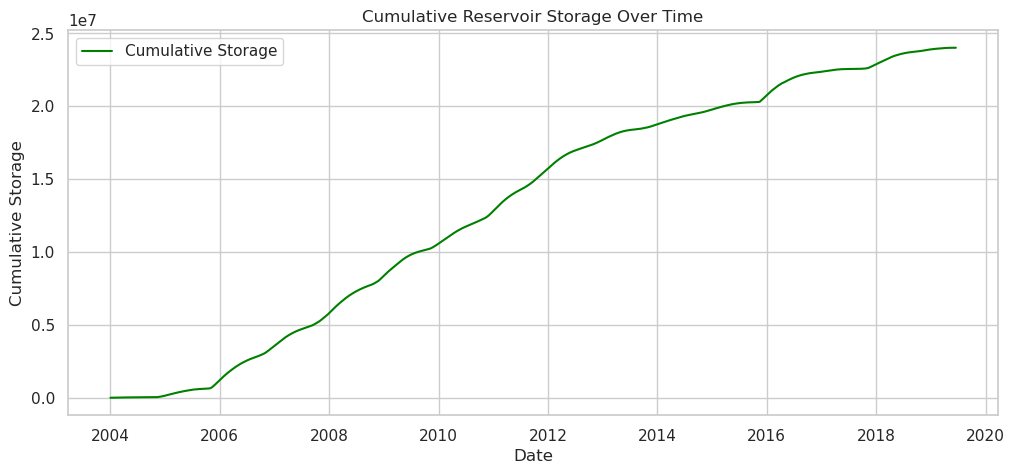

In [15]:
# 6. Cumulative Storage Plot
df['Cumulative'] = df['Total'].cumsum()
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Cumulative'], label="Cumulative Storage", color='green')
plt.xlabel("Date")
plt.ylabel("Cumulative Storage")
plt.title("Cumulative Reservoir Storage Over Time")
plt.legend()
plt.savefig("plots/cumulative_storage.png")
plt.show()

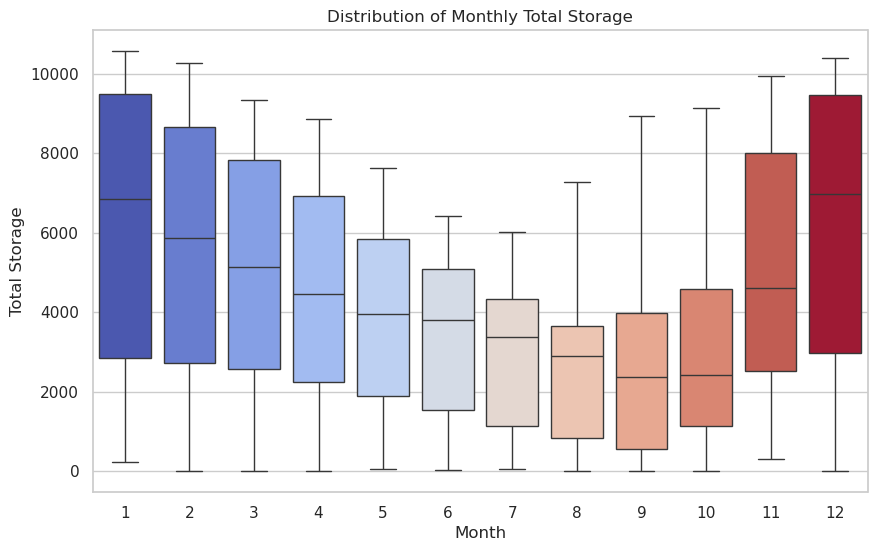

In [50]:

# 7. Boxplot of Monthly Storage
plt.figure(figsize=(10, 6))
sns.boxplot(x='month', y='Total', data=df, hue='month', palette='coolwarm', legend=False)
plt.xlabel("Month")
plt.ylabel("Total Storage")
plt.title("Distribution of Monthly Total Storage")
plt.savefig("plots/monthly_boxplot.png")
plt.show()

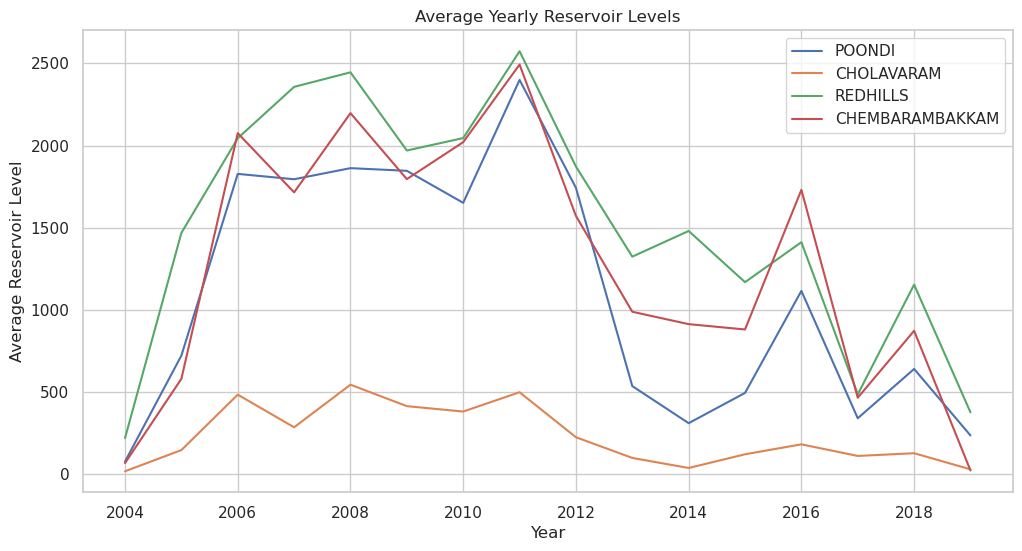

In [51]:
# 8. Lineplot of Average Reservoir Levels per Year
yearly_avg = df.groupby('year')[['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM']].mean().reset_index()
plt.figure(figsize=(12, 6))
for col in ['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM']:
    sns.lineplot(x='year', y=col, data=yearly_avg, label=col)
plt.xlabel("Year")
plt.ylabel("Average Reservoir Level")
plt.title("Average Yearly Reservoir Levels")
plt.legend()
plt.savefig("plots/yearly_avg_reservoirs.png")
plt.show()

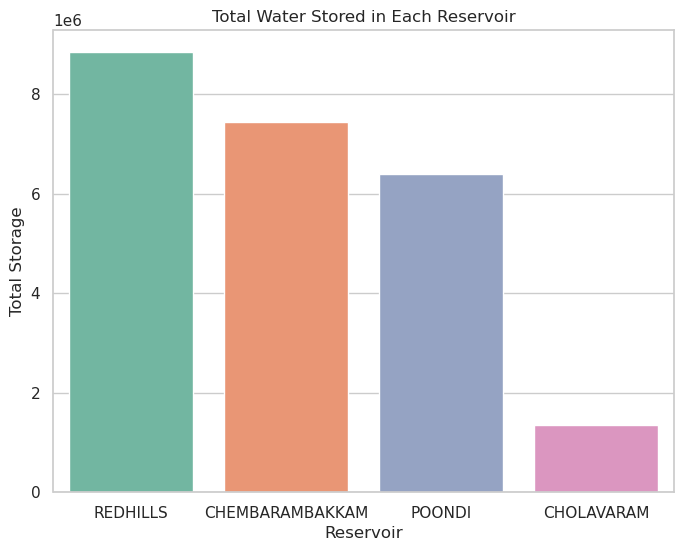

In [54]:
# 9. Barplot: Total Contribution by Reservoir
total_reservoir_sum = df[['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM']].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=total_reservoir_sum.index, y=total_reservoir_sum.values, hue=total_reservoir_sum.index, palette="Set2", legend=False)
plt.title("Total Water Stored in Each Reservoir")
plt.ylabel("Total Storage")
plt.xlabel("Reservoir")
plt.savefig("plots/total_storage_by_reservoir.png")
plt.show()

### Step 6: Final Remarks (Markdown Cell Suggestion)


"""
# Chennai Reservoir Data Analysis Report

##  Project Overview
This project explores the reservoir storage data from Chennai using Python. It focuses on storage levels in four major reservoirs: Poondi, Cholavaram, Redhills, and Chembarambakkam.

##  Key Findings
- Monsoon months show peak storage levels.
- Strong correlation observed between Poondi and Redhills.It means that the water  storage levels in Poondi and Redhills reservoirs change together — when one goes up, the other usually goes up too, and when one drops, the other also drops 
- Year 2015 showed significantly high storage (example).
- ## Key Insights

- Peak storage happens during monsoon months (e.g., Oct–Dec).
- Poondi and Redhills show strong correlation in storage behavior.
- 2015 and 2019 had unusually high water levels (from yearly plots).
- Redhills contributed the highest total water across the years.


## Tools & Libraries

- Python
- Pandas & NumPy (data manipulation)
- Matplotlib & Seaborn (visualization)
- Jupyter Notebook


##  Project Structure
```bash
chennai-reservoir-analysis/
├── data/
│   └── chennai_reservoir_data.csv
├── plots/
│   └── [visual output files]
├── report/
│   └── reservoir_report.ipynb
├── reservoir_analysis.py
├── requirements.txt
└── README.md
```

##  Conclusion
This analysis offers valuable insights into Chennai’s water storage dynamics and seasonal behavior. It serves as a foundation for water management and further climate studies.


Future work could include:
- Adding rainfall data
- Studying reservoir capacity vs usage
- Predictive modeling using ML

---
"""